# Project 2

In [1]:
using DifferentialEquations, Plots, LinearAlgebra

## Goal 2

### (a)

In [2]:
function fhn(u,p,t)
    # define parameters
    a, c, b, beta = p
    v, w = u
    return [
        v * (a-v) * (v-1) - w + beta,
        b * v - c * w
    ]
end

fhn (generic function with 1 method)

### (b)

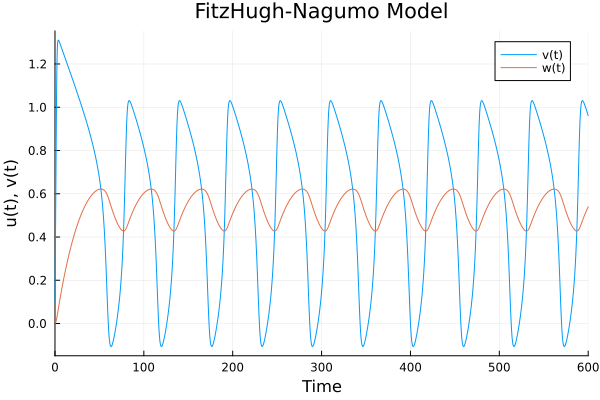

In [3]:
a, b, c = 0.25, 0.02, 0.02
beta1 = 0.5
p1 = (a, b, c, beta1)
u = [0.1, 0]

# solve the system of ODEs
tspan = (0.0, 600.0)
ivp1 = ODEProblem(fhn, u, tspan, p1)
sol1 = solve(ivp1)

# plot the solution
plot(sol1, title="FitzHugh-Nagumo Model", xlabel="Time", ylabel="u(t), v(t)", label=["v(t)" "w(t)"], legend=:topright)

### (c)

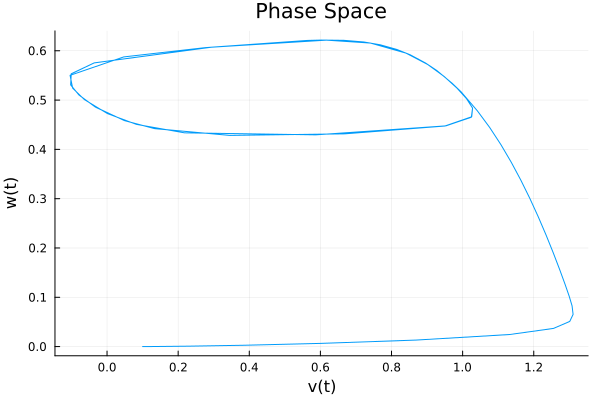

In [4]:
# plot solution in phase space
plot(sol1[1, :], sol1[2, :], title="Phase Space", xlabel="v(t)", ylabel="w(t)", label="Phase Space", legend=false)

### (d)

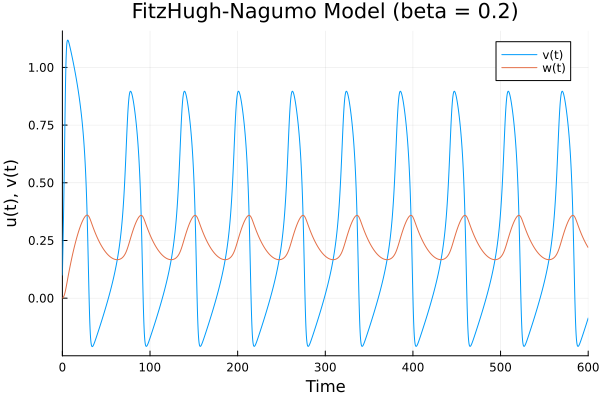

In [5]:
# solution with beta = 0.2
beta2 = 0.2
p2 = (a, b, c, beta2)
ivp2 = ODEProblem(fhn, u, tspan, p2)
sol2 = solve(ivp2)

# plot beta = 0.2 solution
plot(sol2, title="FitzHugh-Nagumo Model (beta = 0.2)", xlabel="Time", ylabel="u(t), v(t)", label=["v(t)" "w(t)"], legend=:topright)


### (e)

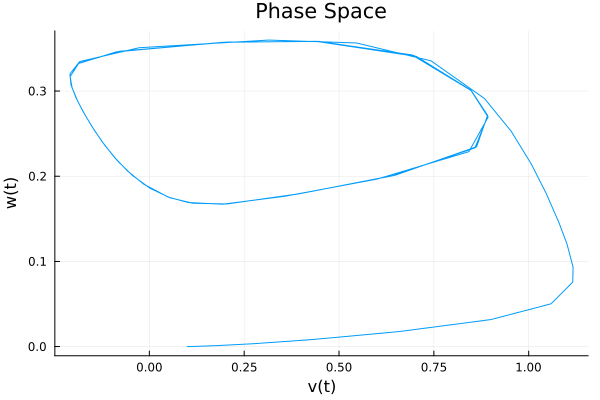

In [6]:
# plot new solution in phase space
plot(sol2[1, :], sol2[2, :], title="Phase Space", xlabel="v(t)", ylabel="w(t)", label="Phase Space", legend=false)

## Goal 3

### (a)

In [56]:
function f(x)
    gamma, T = x
    u = [0.5, gamma]
    tspan = (0.0, T)
    p = (0.25, 0.02, 0.02, 0.5)

    ivp = ODEProblem(fhn, u, tspan, p)
    sol = solve(ivp, Tsit5())
    
    return sol(T) - u
end

f (generic function with 1 method)

### (b)

In [57]:
# from figure 1, I'm estimating a period of around 50 and a gamma of around 0.55
x0 = [0.55, 50.0]

2-element Vector{Float64}:
  0.55
 50.0

### (c)

The code below is taken from https://jamiehaddock.com/164-ScientificComputing/Lecture11/Lecture11.html.

In [58]:
"""
    fdjac(f,x0[,y0])

Compute a finite-difference approximation of the Jacobian matrix for 'f' at 'x0',
where 'y0 = f(x0)' may be given.
"""
function fdjac(f,x0,y0=f(x0))
    δ = sqrt(eps())*max(norm(x0),1)       # FD step size
    m,n = length(y0),length(x0)
    if n == 1
        J = (f(x0+δ) - y0) / δ
    else
        J = zeros(m,n)
        x = copy(x0)
        for j in 1:n
            x[j] += δ
            J[:,j] = (f(x) - y0) / δ
            x[j] -= δ
        end
    end
    return J
end

"""
    levenberg(f,x1[;maxiter,ftol,xtol])

Use Levenberg's quasi-Newton iteration to find a root of the system 'f'
starting from 'x1'.  Returns the history of root estimates as a vector
of vectors.

The optional keyword parameters set the maximum number of iterations and
the stopping tolerance for values of 'f' and changes in 'x'.
"""
function levenberg(f,x1;maxiter=40,ftol=1e-12,xtol=1e-12)
    x = [float(x1)]
    yk = f(x1)
    k = 1; s = Inf;
    A = fdjac(f,x[k],yk)       # start with FD Jacobian
    jac_is_new = true

    λ = 10;
    while (norm(s) > xtol) && (norm(yk) > ftol)
        # Compute the proposed step.
        B = A'*A + λ*I
        z = A'*yk
        s = -(B\z)

        x̂ = x[k] + s
        ŷ = f(x̂)

        # Do we accept the result?
        if norm(ŷ) < norm(yk)     # accept
            λ = λ/10              # get closer to Newton
            # Broyden update of the Jacobian
            A += (ŷ - yk - A*s)*(s'/norm(s)^2)
            jac_is_new = false

            push!(x,x̂)
            yk = ŷ
            k += 1
        else                      # don't accept
            # Get closer to gradient descent.
            λ = 4λ
            # Re-initialize the Jacobian if its out of date.
            if !jac_is_new
                A = fdjac(f,x[k],yk)
                jac_is_new = true
            end
        end
        if k==maxiter
            @warn "Maximum number of iterations reached."
            break
        end
    end
    return x
end

levenberg

In [59]:
solution = levenberg(f, x0; maxiter=400)
gamma_levenberg = solution[end][1]
T_levenberg = solution[end][2]
println("gamma = $gamma_levenberg, T = $T_levenberg")

gamma = 0.42808373130854416, T = 56.66916468647568


### (d)

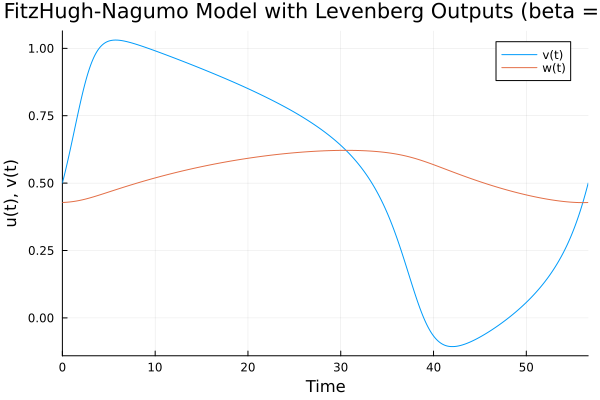

In [60]:
# solution with levenberg output
u = [0.5, gamma_levenberg]
tspan = (0.0, T_levenberg)
ivp3 = ODEProblem(fhn, u, tspan, p1)
sol3 = solve(ivp3)

# plot solution
plot(sol3, title="FitzHugh-Nagumo Model with Levenberg Outputs (beta = 0.5)", xlabel="Time", ylabel="u(t), v(t)", label=["v(t)" "w(t)"], legend=:topright)


$\gamma$ is the value of $w$ at integer periods. $T$ is the period of oscillation for $w(t)$ and $v(t)$.

## Goal 4

### (a)

In [61]:
function fhn2(u, p, t)
    v1, v2, w1, w2 = u
    a, b, c, beta1, beta2, alpha = p
    return [
        v1 * (a - v1) * (v1 - 1) - w1 + beta1 + alpha * v2,
        v2 * (a - v2) * (v2 - 1) - w2 + beta2 + alpha * v1,
        b * v1 - c * w1,
        b * v2 - c * w2
    ]
end

fhn2 (generic function with 1 method)

### (b) and (c)

In [62]:
beta1 = 0.5
beta2 = 0.2
alpha = 0.002
tspan = (0.0, 1000.0)
ivp4 = ODEProblem(fhn2, [0.25, 0.25, 0, 0], tspan, (a, b, c, beta1, beta2, alpha))
sol4 = solve(ivp4)

alpha = 0.05
ivp5 = ODEProblem(fhn2, [0.25, 0.25, 0, 0], tspan, (a, b, c, beta1, beta2, alpha))
sol5 = solve(ivp5)

retcode: Success
Interpolation: 3rd order Hermite
t: 480-element Vector{Float64}:
    0.0
    0.07114080455409169
    0.29946907488556307
    0.6473547728090658
    1.054642029187084
    1.5882087469818895
    2.084586547413624
    2.655688258565639
    3.194869049519636
    3.8868793001752655
    ⋮
  980.833853847076
  982.9432065579851
  984.9840207094411
  986.6569433370588
  989.140711862464
  991.9949293326115
  995.9133657568191
  999.6022782183234
 1000.0
u: 480-element Vector{Vector{Float64}}:
 [0.25, 0.25, 0.0, 0.0]
 [0.28673289303103766, 0.26527388734991614, 0.00038150420214263326, 0.0003662744203650324]
 [0.40905194035705583, 0.3166055372029733, 0.0019622487922320636, 0.0016888538516067252]
 [0.6101051774870031, 0.402766895343974, 0.005472810807669346, 0.0041653761425361]
 [0.8562574830911502, 0.5178215698466193, 0.011380530492977603, 0.007855700756380932]
 [1.1248681093634705, 0.6896867871794065, 0.021872693957116728, 0.014165956796507156]
 [1.261752102125497, 0.85433409476

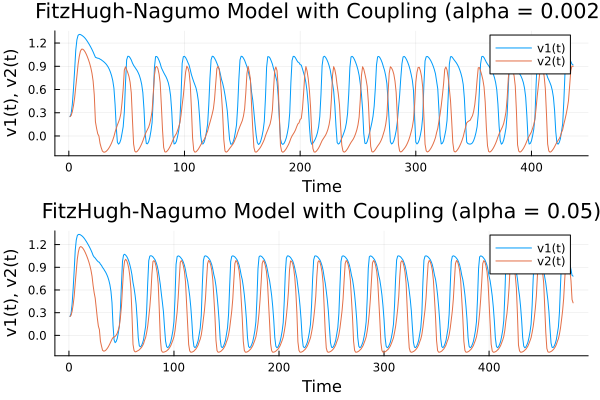

In [70]:
# plot solutions on 2x1 subplot
p = plot(layout = (2, 1))

# plot v1(t) and v2(t)
plot!(p[1, 1], [sol4[1,:], sol4[2,:]], title="FitzHugh-Nagumo Model with Coupling (alpha = 0.002)", xlabel="Time", ylabel="v1(t), v2(t)", label=["v1(t)" "v2(t)"], legend=:topright)
plot!(p[2, 1], [sol5[1,:], sol5[2,:]], title="FitzHugh-Nagumo Model with Coupling (alpha = 0.05)", xlabel="Time", ylabel="v1(t), v2(t)", label=["v1(t)" "v2(t)"], legend=:topright)